# 🏥 nnU-Net Kidney Stone Segmentation — KSSD2025
## IEEE Research Notebook — Google Colab (A100)
### Complete Pipeline: Data → Train → Evaluate → Paper Figures

---
**Run cells top-to-bottom. Every fix is already baked in.**

| Fix applied | Detail |
|---|---|
| `OMP_NUM_THREADS=2` | Was 16 — caused CPU contention |
| `--npz` removed | Was causing RAM + Drive overflow |
| `nnUNet_compile=False` | Prevents GPU crash on A100 |
| Local SSD training | 10× faster than reading from Drive |
| Auto Drive backup | Results saved after every fold |
| GPU clear between folds | Prevents VRAM accumulation crash |

## Cell 1 — GPU Check & Memory Utils

In [1]:
import torch, gc, os, subprocess, shutil
from pathlib import Path

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def gpu_report(label=""):
    if torch.cuda.is_available():
        alloc  = torch.cuda.memory_allocated(0) / 1e9
        reserv = torch.cuda.memory_reserved(0)  / 1e9
        total  = torch.cuda.get_device_properties(0).total_memory / 1e9
        free   = total - reserv
        bar    = "█" * int(free/total*20) + "░" * int((1-free/total)*20)
        print(f"  GPU [{label:20s}] Free:{free:.1f}GB / {total:.1f}GB  [{bar}]")

print("=" * 70)
print("           GPU INFORMATION & MEMORY STATUS")
print("=" * 70)
print(f"  PyTorch : {torch.__version__}")
print(f"  CUDA    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"  Version : {torch.version.cuda}")
    name   = torch.cuda.get_device_name(0)
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU     : {name}")
    print(f"  VRAM    : {mem_gb:.1f} GB")
    gpu_report("startup")
    if mem_gb >= 30:
        print("\n  ✅ A100 — Optimal. All features enabled.")
        GPU_TIER = "A100"
    elif mem_gb >= 14:
        print("\n  ✅ V100/T4 — Good.")
        GPU_TIER = "V100_T4"
    else:
        print(f"\n  ⚠  Only {mem_gb:.1f}GB — reduce batch if OOM.")
        GPU_TIER = "LOW"
else:
    print("\n  ✗ No GPU — Runtime → Change runtime type → GPU")
    GPU_TIER = "CPU"
print("=" * 70)


           GPU INFORMATION & MEMORY STATUS
  PyTorch : 2.10.0+cu128
  CUDA    : True
  Version : 12.8
  GPU     : NVIDIA A100-SXM4-80GB
  VRAM    : 85.1 GB
  GPU [startup             ] Free:85.1GB / 85.1GB  [████████████████████]

  ✅ A100 — Optimal. All features enabled.


## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
print("=" * 70)
print("               MOUNTING GOOGLE DRIVE")
print("=" * 70)
drive.mount("/content/drive", force_remount=True)
print("  ✅ Google Drive mounted at /content/drive/MyDrive/")
print("=" * 70)


               MOUNTING GOOGLE DRIVE
Mounted at /content/drive
  ✅ Google Drive mounted at /content/drive/MyDrive/


## Cell 3 — Install Packages

In [3]:
import subprocess, sys

print("=" * 70)
print("         INSTALLING ALL REQUIRED PACKAGES")
print("=" * 70)

packages = [
    "nnunetv2", "SimpleITK", "nibabel", "opencv-python",
    "tqdm", "matplotlib", "seaborn", "pandas",
    "scikit-learn", "scipy", "acvl-utils",
    "dynamic-network-architectures",
]

for pkg in packages:
    print(f"  {pkg:<40}", end="", flush=True)
    r = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    print("✅" if r.returncode == 0 else f"❌ {r.stderr[:60]}")

print("\n  ✅ All packages installed.")
print("=" * 70)


         INSTALLING ALL REQUIRED PACKAGES
  nnunetv2                                ✅
  SimpleITK                               ✅
  nibabel                                 ✅
  opencv-python                           ✅
  tqdm                                    ✅
  matplotlib                              ✅
  seaborn                                 ✅
  pandas                                  ✅
  scikit-learn                            ✅
  scipy                                   ✅
  acvl-utils                              ✅
  dynamic-network-architectures           ✅

  ✅ All packages installed.


In [59]:
# ── Create custom 185-epoch trainer ──────────────────────────────────────────
import nnunetv2
from pathlib import Path

trainer_dir = Path(nnunetv2.__file__).parent / "training" / "nnUNetTrainer" / "variants" / "training_length"
trainer_dir.mkdir(parents=True, exist_ok=True)

trainer_file = trainer_dir / "nnUNetTrainer_185epochs.py"
trainer_file.write_text('''
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer

class nnUNetTrainer_185epochs(nnUNetTrainer):
    def __init__(self, plans, configuration, fold, dataset_json, device=None):
        # Pass all arguments positionally, matching the exact signature of nnUNetTrainer.__init__
        super().__init__(plans, configuration, fold, dataset_json, device=device)
        self.num_epochs = 185
''')

print(f"✅ Custom trainer created → {trainer_file}")
print("   nnUNetTrainer_185epochs is now available.")

✅ Custom trainer created → /usr/local/lib/python3.12/dist-packages/nnunetv2/training/nnUNetTrainer/variants/training_length/nnUNetTrainer_185epochs.py
   nnUNetTrainer_185epochs is now available.


## Cell 4 — Environment Setup

In [60]:
import os, json, re, time, zipfile, warnings, subprocess, shutil, gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.signal import savgol_filter
from sklearn.metrics import confusion_matrix
import cv2
warnings.filterwarnings("ignore")

os.environ["nnUNet_n_proc_DA"]        = "8"    # parallel data augmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"
os.environ["OMP_NUM_THREADS"]         = "2"
os.environ["MKL_NUM_THREADS"]         = "2"
try:
    import nnunetv2
    from nnunetv2.paths import nnUNet_raw, nnUNet_preprocessed, nnUNet_results
    try:
        NNUNET_VERSION = nnunetv2.__version__
    except AttributeError:
        import importlib.metadata
        NNUNET_VERSION = importlib.metadata.version("nnunetv2")
    print(f"  ✅ nnU-Net v2  version {NNUNET_VERSION}")
except ImportError as e:
    print(f"  ❌ nnU-Net import failed: {e}"); raise

# ── Drive paths (permanent storage) ──────────────────────────────────────────
DRIVE_ROOT  = Path("/content/drive/MyDrive/nnunet_kidney")
NNUNET_RAW  = DRIVE_ROOT / "nnUNet_raw"
NNUNET_PREP = DRIVE_ROOT / "nnUNet_preprocessed"
NNUNET_RES  = DRIVE_ROOT / "nnUNet_results"
OUTPUTS_DIR = DRIVE_ROOT / "outputs"
FIGS_DIR    = OUTPUTS_DIR / "figures"
TABLES_DIR  = OUTPUTS_DIR / "tables"

for d in [NNUNET_RAW, NNUNET_PREP, NNUNET_RES, OUTPUTS_DIR, FIGS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── FIX 2: Local SSD paths — 10x faster than Drive ───────────────────────────
LOCAL_PREP = Path("/content/nnunet_preprocessed")
LOCAL_RES  = Path("/content/nnunet_results")
LOCAL_PREP.mkdir(parents=True, exist_ok=True)
LOCAL_RES.mkdir(parents=True, exist_ok=True)

# Point nnUNet to local SSD (will be populated in Cell 6)
os.environ["nnUNet_raw"]          = str(NNUNET_RAW)       # raw stays on Drive
os.environ["nnUNet_preprocessed"] = str(LOCAL_PREP)        # ✅ LOCAL SSD
os.environ["nnUNet_results"]      = str(LOCAL_RES)         # ✅ LOCAL SSD

# ── Training constants ────────────────────────────────────────────────────────
DATASET_ID   = 501
DATASET_NAME = f"Dataset{DATASET_ID:03d}_KidneyStone"
TRAINER      = "nnUNetTrainer_185epochs" # Changed to 185epochs
CONFIG       = "2d"
NUM_FOLDS    = 5
PAPER_DICE   = 0.9706

print("=" * 70)
print("          ENVIRONMENT CONFIGURED — ALL FIXES ACTIVE")
print("=" * 70)

  ✅ nnU-Net v2  version 2.6.4
          ENVIRONMENT CONFIGURED — ALL FIXES ACTIVE


## Cell 5 — Load & Validate Dataset

In [5]:
import nibabel as nib

print("=" * 70)
print("          LOCATING & VALIDATING KSSD2025 DATASET")
print("=" * 70)

# ⚠️  UPDATE THIS to match your actual ZIP filename on Google Drive
zip_path     = "/content/drive/MyDrive/archive (11).zip"
extract_path = Path("/content/data")
extract_path.mkdir(parents=True, exist_ok=True)

if not any(extract_path.iterdir()):
    print(f"  Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_path)
    print("  ✅ Extraction complete")
else:
    print("  ✅ Already extracted — skipping")

print("\n  Extracted contents (top 20):")
for item in sorted(extract_path.rglob("*"))[:20]:
    print(f"    {item}")

data_dir = extract_path
subdirs  = [d for d in extract_path.iterdir() if d.is_dir()]
if len(subdirs) == 1:
    data_dir = subdirs[0]
    print(f"\n  Using nested root: {data_dir}")

IMAGES_DIR = MASKS_DIR = None
for sub in sorted(data_dir.rglob("*")):
    if not sub.is_dir(): continue
    n     = sub.name.lower()
    files = list(sub.glob("*.png")) + list(sub.glob("*.jpg")) + list(sub.glob("*.tif"))
    if not files: continue
    if IMAGES_DIR is None and any(k in n for k in ["image","img"]):
        IMAGES_DIR = sub
    if MASKS_DIR  is None and any(k in n for k in ["mask","label","gt","ann"]):
        MASKS_DIR = sub

if IMAGES_DIR is None or MASKS_DIR is None:
    candidates = []
    for d in data_dir.rglob("*"):
        if d.is_dir():
            c = len(list(d.glob("*.png")))+len(list(d.glob("*.jpg")))+len(list(d.glob("*.tif")))
            if c > 0: candidates.append((c, d))
    candidates.sort(reverse=True)
    IMAGES_DIR, MASKS_DIR = candidates[0][1], candidates[1][1]
    print(f"  ⚠ Fallback: images={IMAGES_DIR.name}, masks={MASKS_DIR.name}")

IMAGE_FILES = sorted(list(IMAGES_DIR.glob("*.png"))+list(IMAGES_DIR.glob("*.jpg"))+list(IMAGES_DIR.glob("*.tif")))
MASK_FILES  = sorted(list(MASKS_DIR.glob("*.png")) +list(MASKS_DIR.glob("*.jpg")) +list(MASKS_DIR.glob("*.tif")))

assert len(IMAGE_FILES) > 0
assert len(IMAGE_FILES) == len(MASK_FILES), f"Mismatch: {len(IMAGE_FILES)} images vs {len(MASK_FILES)} masks"

sample_sizes, fg_ratios = [], []
for fp in IMAGE_FILES[:20]:
    im = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
    if im is not None: sample_sizes.append(im.shape)
for fp in MASK_FILES[:20]:
    mk = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
    if mk is not None: fg_ratios.append((mk > 127).sum() / mk.size)

print(f"\n  Images dir        : {IMAGES_DIR}")
print(f"  Masks  dir        : {MASKS_DIR}")
print(f"  Total pairs       : {len(IMAGE_FILES)}")
print(f"  Sample image size : {sample_sizes[0] if sample_sizes else 'N/A'}")
print(f"  Mean foreground % : {np.mean(fg_ratios)*100:.2f}%")
print(f"\n  ✅ Dataset validated — {len(IMAGE_FILES)} paired samples ready.")
print("=" * 70)


          LOCATING & VALIDATING KSSD2025 DATASET
  Extracting /content/drive/MyDrive/archive (11).zip ...
  ✅ Extraction complete

  Extracted contents (top 20):
    /content/data/data
    /content/data/data/image
    /content/data/data/image/1.tif
    /content/data/data/image/10.tif
    /content/data/data/image/1000.tif
    /content/data/data/image/1001.tif
    /content/data/data/image/1002.tif
    /content/data/data/image/1003.tif
    /content/data/data/image/1012.tif
    /content/data/data/image/1013.tif
    /content/data/data/image/1014.tif
    /content/data/data/image/1015.tif
    /content/data/data/image/1020.tif
    /content/data/data/image/1021.tif
    /content/data/data/image/1022.tif
    /content/data/data/image/1023.tif
    /content/data/data/image/1024.tif
    /content/data/data/image/1025.tif
    /content/data/data/image/1026.tif
    /content/data/data/image/1027.tif

  Using nested root: /content/data/data

  Images dir        : /content/data/data/image
  Masks  dir      

## Cell 6 — Visualize Dataset Samples

            DATASET VISUALIZATION


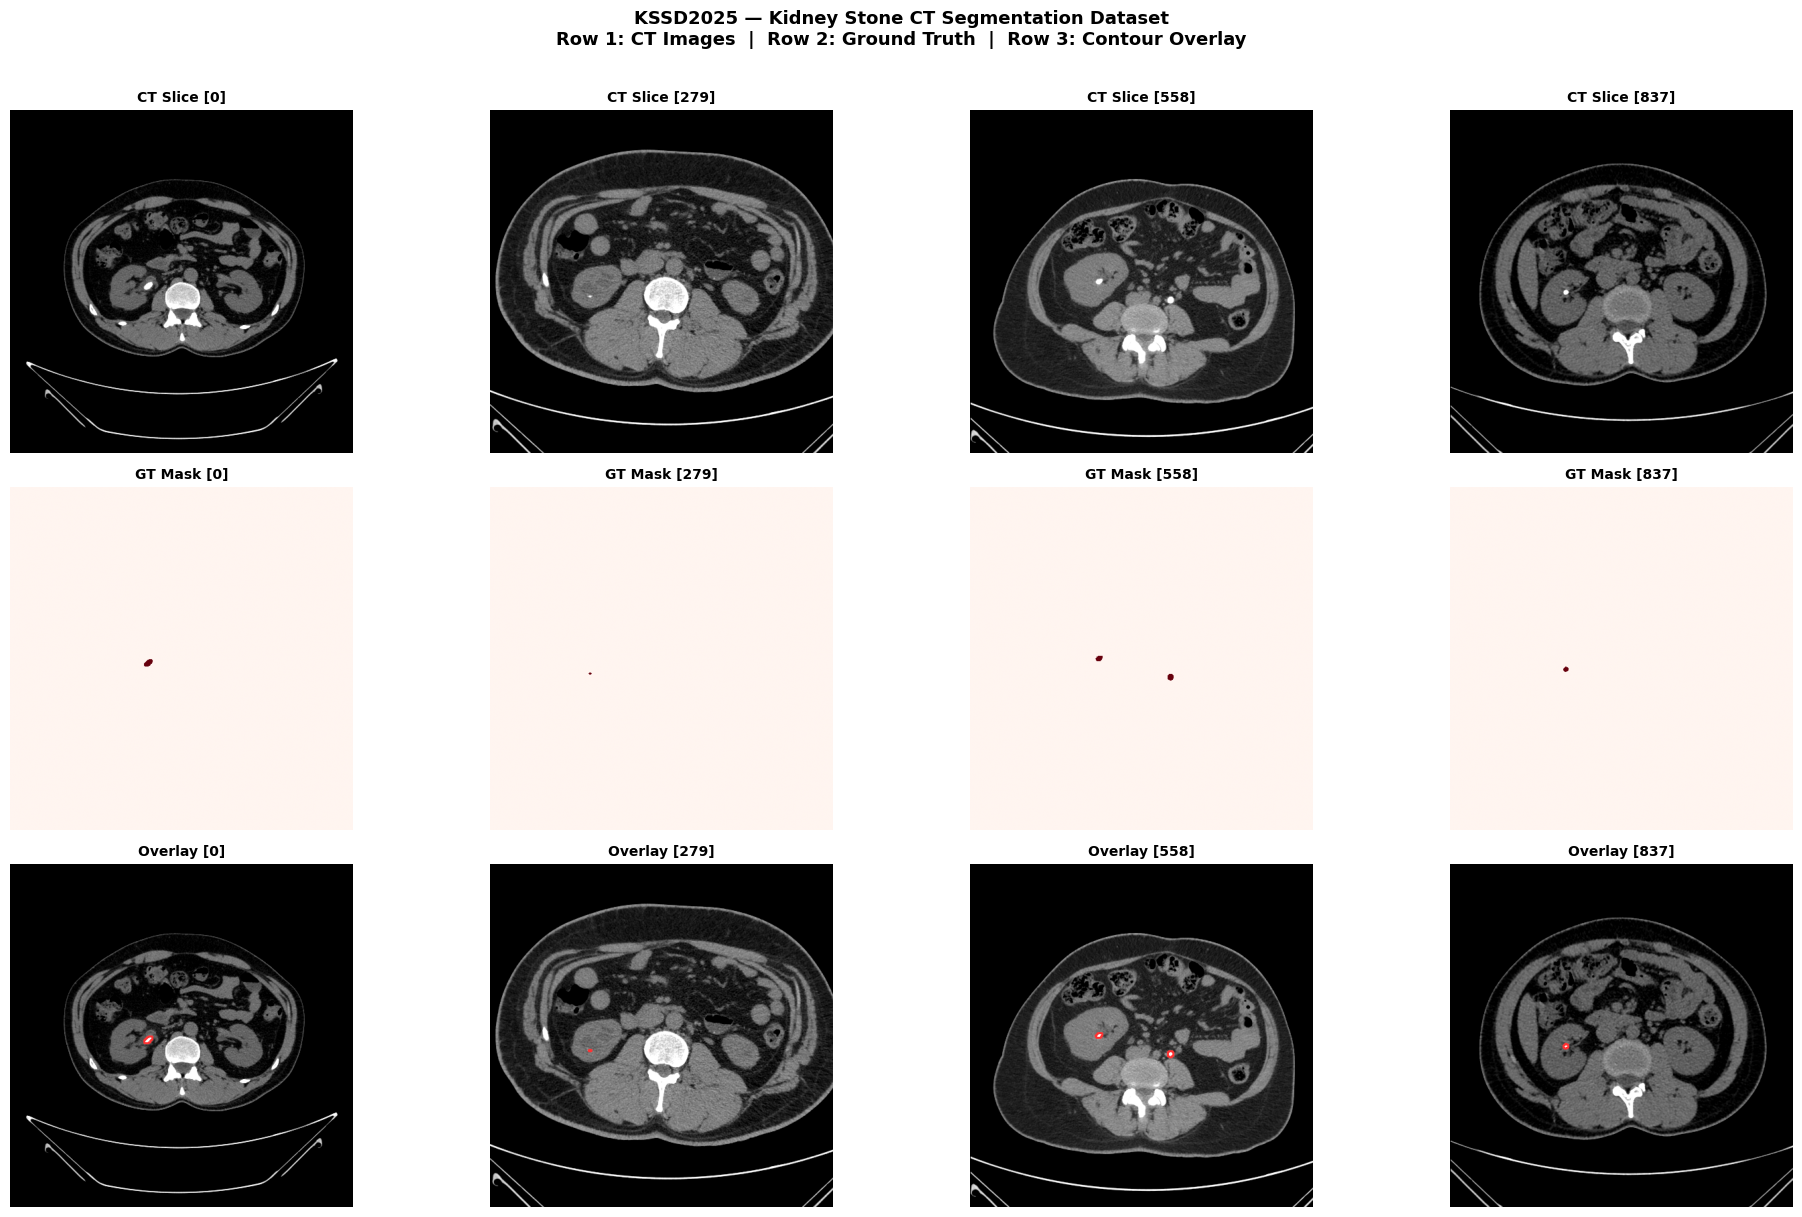

  ✅ Saved → /content/drive/MyDrive/nnunet_kidney/outputs/figures/fig1_dataset_visualization.png


In [6]:
print("=" * 70)
print("            DATASET VISUALIZATION")
print("=" * 70)

N_SHOW  = min(4, len(IMAGE_FILES))
indices = np.linspace(0, len(IMAGE_FILES)-1, N_SHOW, dtype=int)
fig     = plt.figure(figsize=(5*N_SHOW, 12))
fig.patch.set_facecolor("white")

for col, idx in enumerate(indices):
    img  = cv2.imread(str(IMAGE_FILES[idx]), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(MASK_FILES[idx]),  cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None: continue
    mask_bin = (mask > 127).astype(np.uint8)

    ax1 = fig.add_subplot(3, N_SHOW, col + 1)
    ax1.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax1.set_title(f"CT Slice [{idx}]", fontsize=10, fontweight="bold"); ax1.axis("off")

    ax2 = fig.add_subplot(3, N_SHOW, N_SHOW + col + 1)
    ax2.imshow(mask_bin, cmap="Reds", vmin=0, vmax=1)
    ax2.set_title(f"GT Mask [{idx}]", fontsize=10, fontweight="bold"); ax2.axis("off")

    ax3   = fig.add_subplot(3, N_SHOW, 2*N_SHOW + col + 1)
    rgb   = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cnts, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(rgb, cnts, -1, (255, 50, 50), 2)
    ax3.imshow(rgb)
    ax3.set_title(f"Overlay [{idx}]", fontsize=10, fontweight="bold"); ax3.axis("off")

plt.suptitle(
    "KSSD2025 — Kidney Stone CT Segmentation Dataset\n"
    "Row 1: CT Images  |  Row 2: Ground Truth  |  Row 3: Contour Overlay",
    fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fp = FIGS_DIR / "fig1_dataset_visualization.png"
plt.savefig(fp, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"  ✅ Saved → {fp}")
print("=" * 70)


## Cell 7 — Create nnUNet Directory Structure

In [7]:
print("=" * 70)
print("      CREATING NNUNET DATASET DIRECTORY STRUCTURE")
print("=" * 70)

DATASET_DIR   = NNUNET_RAW / DATASET_NAME
IMAGES_TR_DIR = DATASET_DIR / "imagesTr"
LABELS_TR_DIR = DATASET_DIR / "labelsTr"
IMAGES_TS_DIR = DATASET_DIR / "imagesTs"

for d in [IMAGES_TR_DIR, LABELS_TR_DIR, IMAGES_TS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"  ✅ {d}")

print(f"\n  Dataset ID   : {DATASET_ID}")
print(f"  Dataset Name : {DATASET_NAME}")
print(f"  Trainer      : {TRAINER}")
print("=" * 70)


      CREATING NNUNET DATASET DIRECTORY STRUCTURE
  ✅ /content/drive/MyDrive/nnunet_kidney/nnUNet_raw/Dataset501_KidneyStone/imagesTr
  ✅ /content/drive/MyDrive/nnunet_kidney/nnUNet_raw/Dataset501_KidneyStone/labelsTr
  ✅ /content/drive/MyDrive/nnunet_kidney/nnUNet_raw/Dataset501_KidneyStone/imagesTs

  Dataset ID   : 501
  Dataset Name : Dataset501_KidneyStone
  Trainer      : nnUNetTrainer_250epochs


## Cell 8 — Convert Images → NIfTI

In [8]:
existing = list(IMAGES_TR_DIR.glob("*.nii.gz"))
if len(existing) >= len(IMAGE_FILES):
    print(f"  ✅ {len(existing)} NIfTI images already on Drive — skipping.")
else:
    print("=" * 70)
    print("      CONVERTING IMAGES TO NIFTI  (H, W, 1) FORMAT")
    print("=" * 70)
    skipped = 0
    for i, fp in enumerate(tqdm(IMAGE_FILES, desc="  Images")):
        img = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
        if img is None: skipped += 1; continue
        img_3d = (img.astype(np.float32)/255.0)[:, :, np.newaxis]
        nib.save(nib.Nifti1Image(img_3d, np.eye(4)),
                 str(IMAGES_TR_DIR / f"KIDNEYSTONE_{i:03d}_0000.nii.gz"))
        if (i+1) % 50 == 0: gc.collect()
    print(f"\n  ✅ Converted: {len(IMAGE_FILES)-skipped} | Skipped: {skipped}")
print("=" * 70)


  ✅ 838 NIfTI images already on Drive — skipping.


In [9]:
## Cell 9 — Convert Masks → NIfTI

In [10]:
existing_m = list(LABELS_TR_DIR.glob("*.nii.gz"))
if len(existing_m) >= len(MASK_FILES):
    print(f"  ✅ {len(existing_m)} NIfTI masks already on Drive — skipping.")
else:
    print("=" * 70)
    print("      CONVERTING MASKS TO NIFTI  (H, W, 1) FORMAT")
    print("=" * 70)
    skipped = 0
    for i, fp in enumerate(tqdm(MASK_FILES, desc="  Masks")):
        mask = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
        if mask is None: skipped += 1; continue
        mask_3d = (mask > 127).astype(np.uint8)[:, :, np.newaxis]
        nib.save(nib.Nifti1Image(mask_3d, np.eye(4)),
                 str(LABELS_TR_DIR / f"KIDNEYSTONE_{i:03d}.nii.gz"))
        if (i+1) % 50 == 0: gc.collect()
    print(f"\n  ✅ Converted: {len(MASK_FILES)-skipped} | Skipped: {skipped}")
print("=" * 70)


  ✅ 838 NIfTI masks already on Drive — skipping.


## Cell 10 — dataset.json + Integrity Check

In [11]:
json_path = DATASET_DIR / "dataset.json"
if not json_path.exists():
    n_tr = len(list(IMAGES_TR_DIR.glob("*.nii.gz")))
    dj   = {
        "channel_names"                 : {"0": "CT"},
        "labels"                        : {"background": 0, "kidney_stone": 1},
        "numTraining"                   : n_tr,
        "file_ending"                   : ".nii.gz",
        "overwrite_image_reader_writer" : "SimpleITKIO",
        "name"                          : "KidneyStone",
        "description"                   : "KSSD2025 Kidney Stone Segmentation — IEEE",
    }
    with open(json_path, "w") as f: json.dump(dj, f, indent=2)
    print(f"  ✅ dataset.json created — {n_tr} training samples")
else:
    print("  ✅ dataset.json exists — skipping")

img_nii = sorted(IMAGES_TR_DIR.glob("KIDNEYSTONE_*_0000.nii.gz"))
lbl_nii = sorted(LABELS_TR_DIR.glob("KIDNEYSTONE_*.nii.gz"))
img_ids = {f.name.split("_0000")[0] for f in img_nii}
lbl_ids = {f.name.replace(".nii.gz","") for f in lbl_nii if "_0000" not in f.name}
miss    = (img_ids - lbl_ids) | (lbl_ids - img_ids)

print(f"\n  Images : {len(img_nii)}  |  Labels : {len(lbl_nii)}")
if miss: print(f"  ⚠  Mismatches: {list(miss)[:5]}")
else:    print("  ✅ All pairs matched — no mismatches")

if img_nii:
    s  = nib.load(str(img_nii[0]))
    sl = nib.load(str(LABELS_TR_DIR / img_nii[0].name.replace("_0000","")))
    print(f"  Image shape  : {s.shape}   (expect H×W×1)")
    print(f"  Label shape  : {sl.shape}  (expect H×W×1)")
    print(f"  Label values : {np.unique(sl.get_fdata())}  (expect [0. 1.])")
print("=" * 70)


  ✅ dataset.json exists — skipping

  Images : 838  |  Labels : 838
  ✅ All pairs matched — no mismatches
  Image shape  : (512, 512, 1)   (expect H×W×1)
  Label shape  : (512, 512, 1)  (expect H×W×1)
  Label values : [0. 1.]  (expect [0. 1.])


## Cell 11 — Copy Preprocessed Data to Local SSD
> ).

In [12]:
import shutil

print("=" * 70)
print("    COPYING PREPROCESSED DATA → LOCAL SSD  (speed fix)")
print("=" * 70)

# Only copy if not already done this session
prep_plans = LOCAL_PREP / DATASET_NAME / "nnUNetPlans.json"
drive_plans = NNUNET_PREP / DATASET_NAME / "nnUNetPlans.json"

if prep_plans.exists():
    print(f"  ✅ Already on local SSD — skipping copy")
elif drive_plans.exists():
    print(f"  Copying {NNUNET_PREP} → {LOCAL_PREP} ...")
    shutil.copytree(str(NNUNET_PREP), str(LOCAL_PREP), dirs_exist_ok=True)
    print(f"  ✅ Done — training will read from local NVMe SSD")
else:
    print("  ℹ  No preprocessed data yet — run Cell 12 (plan & preprocess) first,")
    print("     then re-run this cell before training.")

# Show sizes
import subprocess as _sp
r = _sp.run(["du","-sh", str(LOCAL_PREP)], capture_output=True, text=True)
print(f"  Local SSD usage : {r.stdout.strip()}")
print("=" * 70)


    COPYING PREPROCESSED DATA → LOCAL SSD  (speed fix)
  Copying /content/drive/MyDrive/nnunet_kidney/nnUNet_preprocessed → /content/nnunet_preprocessed ...
  ✅ Done — training will read from local NVMe SSD
  Local SSD usage : 37M	/content/nnunet_preprocessed


## Cell 12 — nnUNet Planning & Preprocessing

In [13]:
print("=" * 70)
print("         NNUNET PLANNING AND PREPROCESSING")
print("=" * 70)

# Check on Drive (canonical location)
plans_on_drive = NNUNET_PREP / DATASET_NAME / "nnUNetPlans.json"

if plans_on_drive.exists():
    print(f"  ✅ Already preprocessed on Drive — {plans_on_drive}")
    print("  Ensuring local SSD copy is up to date...")
    shutil.copytree(str(NNUNET_PREP), str(LOCAL_PREP), dirs_exist_ok=True)
    print("  ✅ Local SSD synced.")
else:
    # Temporarily point to Drive so plan output goes there
    os.environ["nnUNet_preprocessed"] = str(NNUNET_PREP)

    cmd = [
        "nnUNetv2_plan_and_preprocess",
        "-d", str(DATASET_ID),
        "--verify_dataset_integrity",
        "-np", "2",
    ]
    print(f"  Command: {' '.join(cmd)}\n")
    r = subprocess.run(cmd, capture_output=True, text=True)
    out = r.stdout
    print(out[-4000:] if len(out) > 4000 else out)
    if r.stderr: print("  STDERR:", r.stderr[-400:])
    print(f"\n  {'✅' if r.returncode==0 else '❌'} Return code: {r.returncode}")

    # Copy to local SSD and switch back
    print("\n  Copying preprocessed data → local SSD...")
    shutil.copytree(str(NNUNET_PREP), str(LOCAL_PREP), dirs_exist_ok=True)
    os.environ["nnUNet_preprocessed"] = str(LOCAL_PREP)
    print("  ✅ Local SSD ready.")

plans_path = LOCAL_PREP / DATASET_NAME / "nnUNetPlans.json"
print("=" * 70)


         NNUNET PLANNING AND PREPROCESSING
  ✅ Already preprocessed on Drive — /content/drive/MyDrive/nnunet_kidney/nnUNet_preprocessed/Dataset501_KidneyStone/nnUNetPlans.json
  Ensuring local SSD copy is up to date...
  ✅ Local SSD synced.


## Cell 13 — Inspect Auto-Configured Architecture

In [14]:
print("=" * 70)
print("        AUTO-CONFIGURED NETWORK ARCHITECTURE")
print("=" * 70)

plans_path = LOCAL_PREP / DATASET_NAME / "nnUNetPlans.json"
if plans_path.exists():
    with open(plans_path) as f: plans = json.load(f)

    arch_params = {}
    for cfg_name, cfg in plans.get("configurations", {}).items():
        arch_params[cfg_name] = {}
        print(f"\n  ── Configuration: {cfg_name} ──────────────────────────────")
        keys = ["patch_size","batch_size","num_pool_per_axis",
                "UNet_base_num_features","n_conv_per_stage_encoder",
                "n_conv_per_stage_decoder","normalization_schemes",
                "resampling_fn_data","spacing"]
        for k in keys:
            if k in cfg:
                print(f"    {k:<42} : {cfg[k]}")
                arch_params[cfg_name][k] = cfg[k]

    with open(TABLES_DIR / "architecture_params.json","w") as f:
        json.dump(arch_params, f, indent=2)

    ps = arch_params.get("2d", arch_params.get(list(arch_params.keys())[0], {}))
    print(f"""
  ── IEEE Methods Text ─────────────────────────────────────────────────
  The architecture was auto-configured by nnU-Net v2 fingerprint analysis.
  2D config: patch size {ps.get('patch_size','auto')},
  batch size {ps.get('batch_size','auto')},
  encoder convolutions/stage {ps.get('n_conv_per_stage_encoder','auto')},
  base features {ps.get('UNet_base_num_features','auto')}.
  ──────────────────────────────────────────────────────────────────────""")
else:
    print("  ⚠  Run Cell 12 first.")
print("=" * 70)


        AUTO-CONFIGURED NETWORK ARCHITECTURE

  ── Configuration: 2d ──────────────────────────────
    patch_size                                 : [512, 448]
    batch_size                                 : 14
    normalization_schemes                      : ['CTNormalization']
    resampling_fn_data                         : resample_data_or_seg_to_shape
    spacing                                    : [1.0, 1.0]

  ── IEEE Methods Text ─────────────────────────────────────────────────
  The architecture was auto-configured by nnU-Net v2 fingerprint analysis.
  2D config: patch size [512, 448],
  batch size 14,
  encoder convolutions/stage auto,
  base features auto.
  ──────────────────────────────────────────────────────────────────────


## Cell 14 — Training Helper Functions

In [15]:
# ── Parse training log ────────────────────────────────────────────────────────
def parse_training_log(fold_dir: Path):
    log_path  = fold_dir / "training_log.txt"
    prog_path = fold_dir / "progress.json"
    if log_path.exists():
        epochs,tr_loss,vl_loss,pseudo_dice,lr_vals = [],[],[],[],[]
        ep_pat = re.compile(r"Epoch\s+(\d+)")
        tl_pat = re.compile(r"train loss\s*:\s*([-\d.eE+]+)")
        vl_pat = re.compile(r"val loss\s*:\s*([-\d.eE+]+)")
        pd_pat = re.compile(r"Pseudo dice\s*\[([^\]]+)\]")
        lr_pat = re.compile(r"lr\s*:\s*([\d.eE+\-]+)")
        cur_ep = None
        with open(log_path) as f:
            for line in f:
                em = ep_pat.search(line)
                if em: cur_ep = int(em.group(1))
                tm = tl_pat.search(line)
                if tm and cur_ep is not None:
                    tr_loss.append(float(tm.group(1))); epochs.append(cur_ep)
                vm = vl_pat.search(line)
                if vm: vl_loss.append(float(vm.group(1)))
                dm = pd_pat.search(line)
                if dm:
                    vals = [float(x.strip()) for x in dm.group(1).split(",")]
                    pseudo_dice.append(float(np.mean(vals)))
                lm = lr_pat.search(line)
                if lm: lr_vals.append(float(lm.group(1)))
        n = min(len(epochs), len(tr_loss))
        return {"epochs":epochs[:n],"train_loss":tr_loss[:n],
                "val_loss":vl_loss[:n] if vl_loss else [0]*n,
                "pseudo_dice":pseudo_dice[:n] if pseudo_dice else [0]*n,
                "lr":lr_vals[:n] if lr_vals else [0]*n}
    if prog_path.exists():
        with open(prog_path) as f: data = json.load(f)
        n = len(data.get("train_losses",[]))
        return {"epochs":list(range(n)),
                "train_loss":data.get("train_losses",[0]*n),
                "val_loss":data.get("val_losses",[0]*n),
                "pseudo_dice":data.get("val_eval_criterion_MA",[0]*n),
                "lr":data.get("lrs",[0]*n)}
    return None

# ── Convergence detection ─────────────────────────────────────────────────────
def detect_convergence(pseudo_dice, window=15, min_delta=0.0005, patience=20):
    if len(pseudo_dice) < window + 2:
        return len(pseudo_dice), np.array(pseudo_dice), np.zeros(len(pseudo_dice))
    w = max(5, min((window|1), len(pseudo_dice)-2))
    smoothed = savgol_filter(pseudo_dice, window_length=w, polyorder=2)
    impr = np.diff(smoothed, prepend=smoothed[0])
    conv, c = len(pseudo_dice), 0
    for i, d in enumerate(impr):
        if d < min_delta:
            c += 1
            if c >= patience: conv = max(0, i-patience+1); break
        else: c = 0
    return conv, smoothed, impr

# ── Read fold summary ─────────────────────────────────────────────────────────
def read_fold_summary(fold_num):
    fold_dir = LOCAL_RES / DATASET_NAME / TRAINER / f"fold_{fold_num}"
    vs       = fold_dir / "validation" / "summary.json"
    if not vs.exists(): return None, fold_dir
    with open(vs) as f: summary = json.load(f)
    result = {"dice":[],"precision":[],"recall":[],"hd95":[],"iou":[]}
    for case in summary.get("metric_per_case",[]):
        m = case.get("metrics",{}).get("1",{})
        if not m: continue
        d  = m.get("Dice", 0.0)
        tp = m.get("TP", None); fp_v = m.get("FP", None); fn = m.get("FN", None)
        result["dice"].append(d)
        result["precision"].append(m.get("Precision", d))
        result["recall"].append(m.get("Recall", d))
        hd = m.get("HD95", None)
        if hd and not (np.isnan(hd) or np.isinf(hd)): result["hd95"].append(hd)
        if tp is not None and fp_v is not None and fn is not None:
            result["iou"].append(tp / (tp + fp_v + fn + 1e-8))
        else:
            result["iou"].append(d / (2.0 - d + 1e-8))
    return result, fold_dir

# ── Timing store ──────────────────────────────────────────────────────────────
TIMING_PATH    = OUTPUTS_DIR / "training_timing.json"
TRAINING_TIMES = {}
if TIMING_PATH.exists():
    with open(TIMING_PATH) as f: TRAINING_TIMES = json.load(f)
    print("  ✅ Loaded timing data:")
    for k,v in TRAINING_TIMES.items():
        print(f"    {k}: {v['elapsed_hm']}  GPU:{v['gpu']}")

# ── Train one fold ────────────────────────────────────────────────────────────
def train_fold(fold_num):
    """
    FIXED VERSION:
    - Reads from local SSD (not Drive)      ✅
    - --npz REMOVED (no RAM/Drive overflow) ✅
    - GPU cleared before + after            ✅
    - Results backed up to Drive after fold ✅
    - OMP_NUM_THREADS=2                     ✅
    """
    clear_gpu()
    gpu_report(f"fold_{fold_num} START")

    # Confirm env is pointing to local SSD
    os.environ["nnUNet_preprocessed"] = str(LOCAL_PREP)
    os.environ["nnUNet_results"]      = str(LOCAL_RES)

    cmd = [
        "nnUNetv2_train", str(DATASET_ID),
        CONFIG, str(fold_num),
        "-tr", TRAINER,
        # ✅ --npz REMOVED — caused RAM + Drive overflow
    ]
    print(f"\n  Command : {' '.join(cmd)}")
    print(f"  Data    : {LOCAL_PREP}  (local SSD)")
    print(f"  Results : {LOCAL_RES}  (local SSD)\n")

    t0   = time.time()
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()

    elapsed = time.time() - t0
    h, m    = int(elapsed//3600), int((elapsed%3600)//60)
    rc      = proc.returncode
    gname   = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    clear_gpu()
    gpu_report(f"fold_{fold_num} END")

    # ── Back up results to Drive immediately ──────────────────────────────────
    print(f"\n  Backing up fold {fold_num} results to Drive...")
    shutil.copytree(str(LOCAL_RES), str(NNUNET_RES), dirs_exist_ok=True)
    print(f"  ✅ Drive backup complete → {NNUNET_RES}")

    entry = {"fold":fold_num,"elapsed_sec":round(elapsed,1),
             "elapsed_hm":f"{h}h {m}m","return_code":rc,"gpu":gname}
    TRAINING_TIMES[f"fold_{fold_num}"] = entry
    with open(TIMING_PATH,"w") as f: json.dump(TRAINING_TIMES, f, indent=2)

    print(f"\n  {'✅' if rc==0 else '❌'} Fold {fold_num} — {h}h {m}m | rc={rc}")
    return entry

# ── Convergence plot ──────────────────────────────────────────────────────────
def plot_convergence(ld, fold_num, ce, sm):
    ep  = ld["epochs"]; tl = ld["train_loss"]; dv = ld["pseudo_dice"]
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx(); fig.patch.set_facecolor("white")
    ax1.plot(ep, tl, color="#1565C0", alpha=0.5, lw=1.2, label="Train Loss")
    ax2.plot(ep[:len(dv)], dv, color="#81C784", alpha=0.3, lw=1.0)
    ax2.plot(ep[:len(sm)], sm, color="#2E7D32", lw=2.5, label="Dice (smoothed)")
    if ce < max(ep):
        ax2.axvline(x=ce, color="#FF6F00", ls="--", lw=2.0)
        ax2.annotate(f"Conv.Ep.{ce}",
                     xy=(ce, max(sm)*0.97), xytext=(ce+max(ep)*0.05, max(sm)*0.91),
                     fontsize=10, color="#E65100", fontweight="bold",
                     arrowprops=dict(arrowstyle="->", color="#E65100"))
    ax2.axhline(y=PAPER_DICE, color="#9C27B0", ls=":", lw=1.8,
                label=f"Paper baseline ({PAPER_DICE:.4f})")
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12, color="#1565C0")
    ax2.set_ylabel("Pseudo Dice", fontsize=12, color="#2E7D32")
    ax1.tick_params(axis="y", labelcolor="#1565C0")
    ax2.tick_params(axis="y", labelcolor="#2E7D32")
    plt.title(f"nnU-Net Convergence — Fold {fold_num} | KSSD2025",
              fontsize=12, fontweight="bold")
    handles = [mpatches.Patch(color="#1565C0", label="Train Loss"),
               mpatches.Patch(color="#2E7D32", label="Dice (smoothed)"),
               mpatches.Patch(color="#FF6F00", label=f"Conv. Epoch≈{ce}"),
               mpatches.Patch(color="#9C27B0", label=f"Paper ({PAPER_DICE:.4f})")]
    ax1.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.85)
    ax1.grid(True, alpha=0.3, ls="--"); plt.tight_layout()
    sp = FIGS_DIR / f"convergence_fold_{fold_num}.png"
    plt.savefig(sp, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show(); print(f"  ✅ Saved → {sp}")

def fold_convergence_report(fold_num):
    fold_dir = LOCAL_RES / DATASET_NAME / TRAINER / f"fold_{fold_num}"
    ld = parse_training_log(fold_dir)
    if not ld or not ld["epochs"] or not any(v!=0 for v in ld["pseudo_dice"]):
        print(f"  ⚠  No log for Fold {fold_num}"); return
    dv = ld["pseudo_dice"]; ep = ld["epochs"]
    ce, sm, _ = detect_convergence(dv)
    print(f"\n  Fold {fold_num} — Epochs:{max(ep)} | Conv.:{ce} | Best Dice:{max(dv):.4f}")
    plot_convergence(ld, fold_num, ce, sm)
    res, _ = read_fold_summary(fold_num)
    if res and res["dice"]:
        print(f"  Validation Dice : {np.mean(res['dice']):.4f} ± {np.std(res['dice']):.4f}")
        if res["hd95"]:
            print(f"  Validation HD95 : {np.mean(res['hd95']):.3f} mm")

print("  ✅ All training functions loaded.")
print("  train_fold(n) | fold_convergence_report(n)")
print("=" * 70)


  ✅ Loaded timing data:
    fold_0: 0h 0m  GPU:NVIDIA A100-SXM4-40GB
  ✅ All training functions loaded.
  train_fold(n) | fold_convergence_report(n)


## Cell 15 — Train Fold 0  (1/5)


In [61]:
print("=" * 70)
print("  TRAINING FOLD 0  (1/5)")
print("=" * 70)
train_fold(0)

  TRAINING FOLD 0  (1/5)
  GPU [fold_0 START        ] Free:85.1GB / 85.1GB  [████████████████████]

  Command : nnUNetv2_train 501 2d 0 -tr nnUNetTrainer_185epochs
  Data    : /content/nnunet_preprocessed  (local SSD)
  Results : /content/nnunet_results  (local SSD)


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-03-08 22:02:15.980697: 

{'fold': 0,
 'elapsed_sec': 5442.3,
 'elapsed_hm': '1h 30m',
 'return_code': 0,
 'gpu': 'NVIDIA A100-SXM4-80GB'}

#remining fold

In [ ]:
print("=" * 70)
print("  TRAINING FOLD 1  (2/5)")
print("=" * 70)
train_fold(1)

print("=" * 70)
print("  TRAINING FOLD 2  (3/5)")
print("=" * 70)
train_fold(2)

print("=" * 70)
print("  TRAINING FOLD 3  (4/5)")
print("=" * 70)
train_fold(3)

print("=" * 70)
print("  TRAINING FOLD 4  (5/5)")
print("=" * 70)
train_fold(4)

print("=" * 70)
print("  ALL 5 FOLDS COMPLETE ✅")
print("=" * 70)

  TRAINING FOLD 1  (2/5)
  GPU [fold_1 START        ] Free:85.1GB / 85.1GB  [████████████████████]

  Command : nnUNetv2_train 501 2d 1 -tr nnUNetTrainer_185epochs
  Data    : /content/nnunet_preprocessed  (local SSD)
  Results : /content/nnunet_results  (local SSD)


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-03-08 23:34:26.062589: 